In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import sunspots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [8]:
data = sunspots.load_pandas().data
data["YEAR"]=pd.to_datetime(data["YEAR"])
data.set_index('YEAR', inplace=True)
series = data["SUNACTIVITY"]

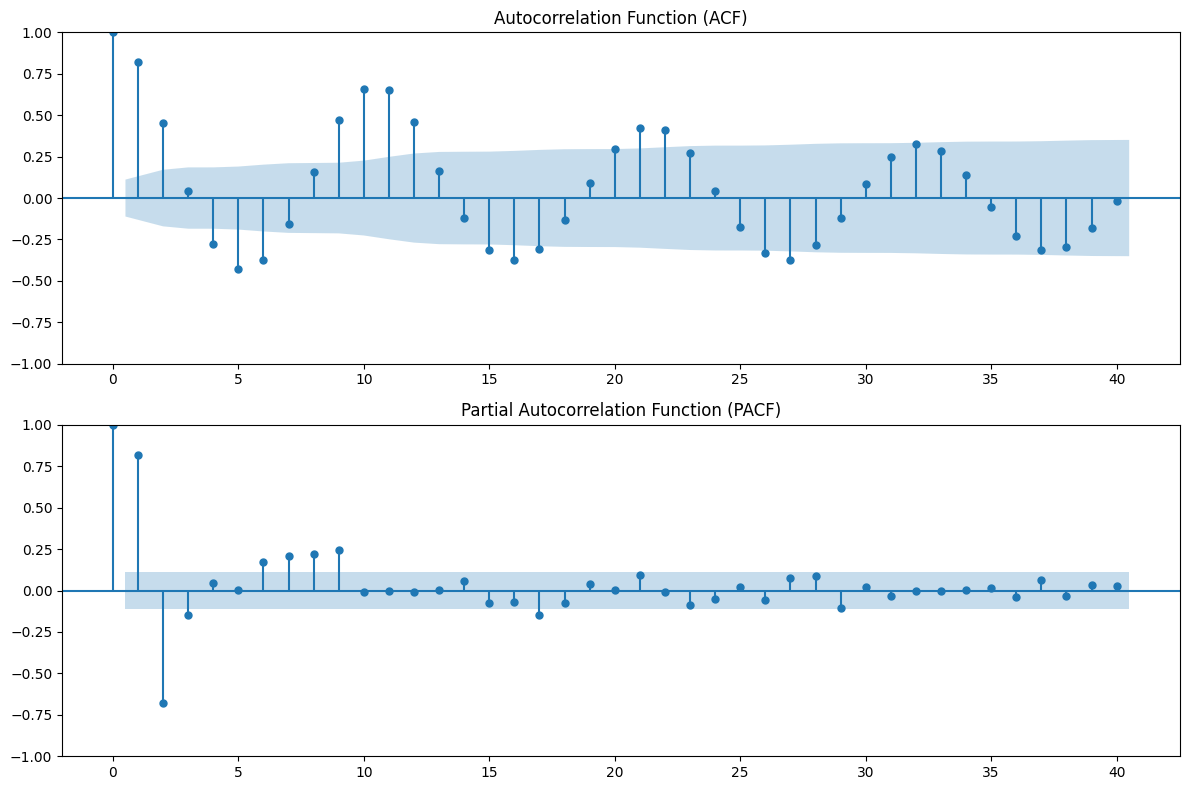

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12,8))

plot_acf(series, ax=axes[0], lags=40)
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(series, ax=axes[1], lags=40, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [11]:
model = ARIMA(series, order=(2, 1, 2))
model_fit=model.fit()

model_fit.summary()


c:\Users\RAJ SINGH\Documents\Semester Exams\SEM 6\DAV\Coding\dav_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
c:\Users\RAJ SINGH\Documents\Semester Exams\SEM 6\DAV\Coding\dav_venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            SUNACTIVITY   No. Observations:                  309
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1283.163
Date:                Tue, 29 Apr 2025   AIC                           2576.326
Time:                        07:31:29   BIC                           2594.976
Sample:                    01-01-1970   HQIC                          2583.783
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6098      0.026     61.536      0.000       1.559       1.661
ar.L2         -0.9381      0.023    -41.582      0.000      -0.982      -0.894
ma.L1         -1.5185      0.055    -27.634      0.000      -1.626      -1.411
ma.L2          0.6440      0.059     10.857      0.000       0.528       0.760
sigma2       240.9492     16.173     14.898      0.000     209.250     272.648
===================================================================================
Ljung-Box (L1) (Q):                   2.33   Jarque-Bera (JB):                55.99
Prob(Q):                              0.13   Prob(JB):                         0.00
Heteroskedasticity (H):               1.26   Skew:                             0.63
Prob(H) (two-sided):                  0.24   Kurtosis:                         4.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
# Predict
start = len(series) - 50  # Last 50 points for visualization
end = len(series) + 20    # Forecast 20 steps ahead

predictions = model_fit.predict(start=start, end=end, typ='levels')

c:\Users\RAJ SINGH\Documents\Semester Exams\SEM 6\DAV\Coding\dav_venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


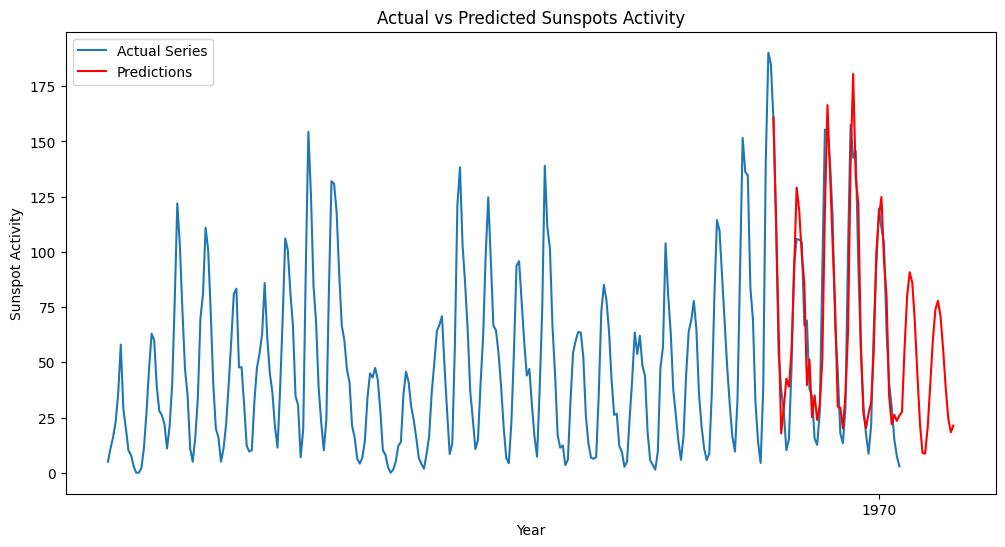

In [13]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(series, label='Actual Series')
plt.plot(predictions, label='Predictions', color='red')
plt.title('Actual vs Predicted Sunspots Activity')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.legend()
plt.show()